# Fourier Series Demonstration

In this notebook we deomnstrate the calculation procedure of fourier series; followed by its reconstruction

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt 
from scipy import integrate

For the purpose of this demonstration we use a square wave

In [4]:
T = 10
# periodicity of the signal 
t = sp.symbols("t")
y = sp.Piecewise((1, t%T<=T/2), (0, t%T>T/2))
x = sp.Piecewise((t - (t//T)*T, t%T<=T/4), (T/2 + (t//T)*T - t, (t%T>T/4) & (t%T<=3*T/4)), (t-T - (t//T)*T, (t%T>3*T/4) & (t%T<=T)))

## Plotting the signal 

The above signal is in symbolic form. We need to convert this into a numerical form

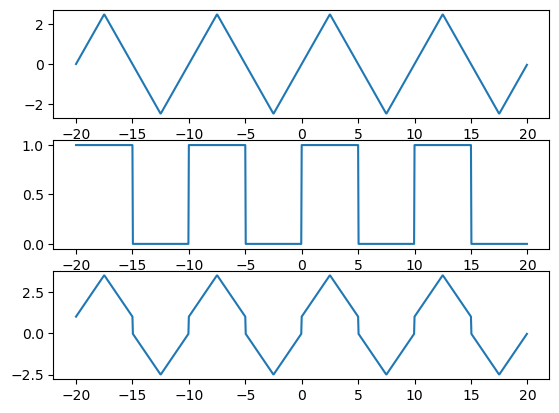

In [5]:
tvec = np.linspace(-2*T, 2*T, 1000, endpoint=False)
xnum = sp.lambdify(t, x)
ynum = sp.lambdify(t, y)
xynum = sp.lambdify(t, x+y)

fig, axes = plt.subplots(3)

axes[0].plot(tvec, xnum(tvec))
axes[1].plot(tvec, ynum(tvec))
axes[2].plot(tvec, xynum(tvec))

In [6]:
sp.integrate(x, (t, 0, T))

Integral(Piecewise((t - 10*floor(t/10), Mod(t, 10) <= 2.5), (-1.0*t + 10.0*floor(t/10) + 5.0, Mod(t, 10) <= 7.5), (t - 10*floor(t/10) - 10, Mod(t, 10) <= 10)), (t, 0, 10))

The symbolic integration does not work here ! 

Probably the use of modulo function has confused the computation here

In [7]:
sp.integrate(1, (t, 0, T/2))
print(T)
integrate.quad(ynum , 0, T)[1]

10


5.595524044110789e-14

Thus we jump to numerical integration at this stage. 

To perform the numerical integration we need to define a function which returns the value of the integrand. Thus, we will implement the integration in two parts namely - the real and the imaginary

In [8]:
def realintegrand(t, f, n):
    '''This function returns the real part of the integrand used in
    the Fourier series integral'''
    w0 = 2*np.pi/T
    trig = np.cos(n*w0*t)
    return f(t)*trig/T

def imagintegrand(t, f, n):
    '''This function returns the imaginary part of the integrand used in
    the Fourier series integral'''
    w0 = 2*np.pi/T
    trig = np.sin(n*w0*t)
    return f(t)*trig/T

def fourier_coefficient(f, n):
    realans, errreal = integrate.quad(realintegrand, 0, T, args=(f, n,))
    imagans, errimag = integrate.quad(imagintegrand, 0, T, args=(f, n,))
    return realans-1.0j*imagans

In [9]:
fourier2 = np.vectorize(fourier_coefficient)

N = 90
nvec = np.arange(-N, N, 1)
X = fourier2(xnum, nvec)

/tmp/ipykernel_5795/3713553212.py:17: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  imagans, errimag = integrate.quad(imagintegrand, 0, T, args=(f, n,))


## Plotting the Fourier Coefficients

/tmp/ipykernel_5795/2561201851.py:1: MatplotlibDeprecationWarning: Passing the linefmt parameter positionally is deprecated since Matplotlib 3.5; the parameter will become keyword-only two minor releases later.
  plt.stem(nvec, np.abs(X),'r', markerfmt = 'ro', use_line_collection=True)


Text(0.5, 0, 'Order of the Fourier Coefficients')

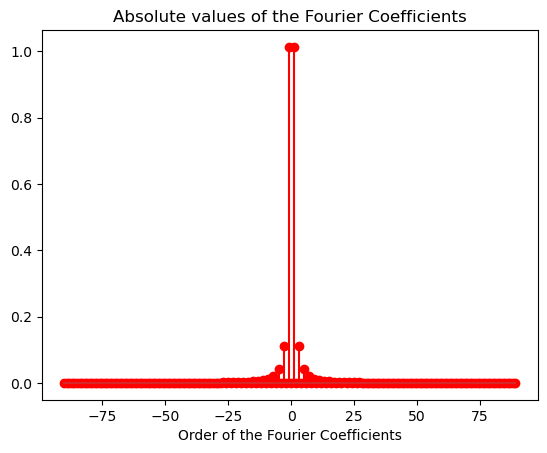

In [13]:
plt.stem(nvec, np.abs(X),'r', markerfmt = 'ro', use_line_collection=True)
plt.title('Absolute values of the Fourier Coefficients')
plt.xlabel('Order of the Fourier Coefficients')

Text(0.5, 0, 'Order of the Fourier Coefficients')

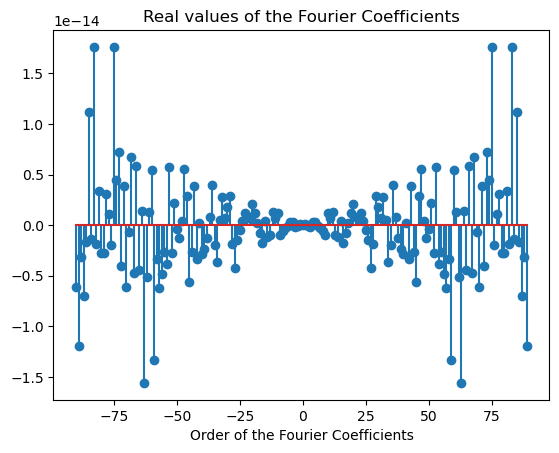

In [20]:
plt.stem(nvec, np.real(X), use_line_collection=True)
plt.title('Real values of the Fourier Coefficients')
plt.xlabel('Order of the Fourier Coefficients')

Text(0.5, 0, 'Order of the Fourier Coefficients')

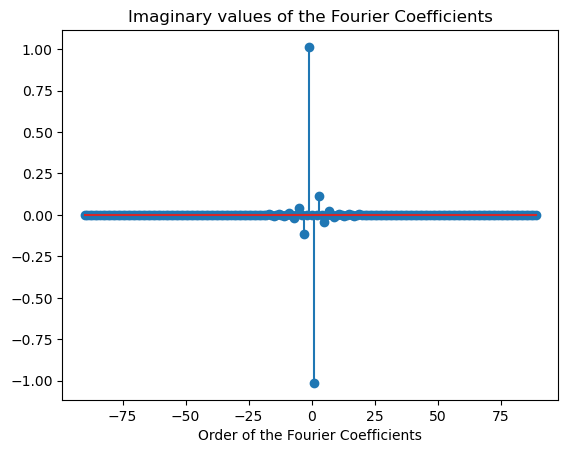

In [21]:
plt.stem(nvec, np.imag(X), use_line_collection=True)
plt.title('Imaginary values of the Fourier Coefficients')
plt.xlabel('Order of the Fourier Coefficients')

## Parseval's theorem 

Power in time domain 

In [23]:
sp.integrate(x, (t, 0, T/2))/T
# integrate.quad(xnum, 0, T) /T

Integral(Piecewise((t - 10*floor(t/10), Mod(t, 10) <= 2.5), (-1.0*t + 10.0*floor(t/10) + 5.0, Mod(t, 10) <= 7.5), (t - 10*floor(t/10) - 10, Mod(t, 10) <= 10)), (t, 0, 5.0))/10

In [24]:
np.sum(np.abs(Y)**2)

NameError: name 'Y' is not defined

# Reconstruction 
Using the Fourier coefficients we will now reconstruct the time signal 

In [ ]:
recon = np.zeros_like(tvec, dtype=complex)
w0 = 2*np.pi/T 
count1 = 0 
    
for count in nvec:
    n = nvec[count1]
    argmnt = n*w0*tvec
    cexp = np.exp(1.0j*argmnt)
    recon = recon+XY[count1]*cexp 
    count1 = count1+1 

In [ ]:
plt.plot(tvec, np.real(recon))

In [ ]:
# %matplotlib notebook

In [ ]:
plt.plot(tvec, np.real(recon))